# Scikit-Learn Ledoit-Wolf on NVIDIA cuML — Taming Portfolio Turnover
---

**TL;DR — Run `%load_ext cuml.accel` before your sklearn imports and `sklearn.covariance.LedoitWolf`
runs on your NVIDIA GPU. This notebook uses that one line to take a 6-run portfolio-churn benchmark
(3 optimizers × {sample covariance, Ledoit-Wolf}) from CPU-minutes to GPU-seconds — zero code changes.**

The rendering of this notebook is from a Threadripper PRO 7965WX + RTX PRO 6000 Blackwell.

---

## What this notebook is and isn't

This notebook **is** an educational benchmark on a recognizable quant workload: rolling backtests of
**Minimum-Variance, Mean-Variance, and Risk-Parity** portfolios over a wide intraday equity universe,
each run twice — once on the raw **sample covariance**, once on **Ledoit-Wolf shrinkage** — to measure
how much *turnover* ("churn") shrinkage removes, and how fast the whole thing runs on CPU vs GPU.

This notebook **is not:**

- **A trading strategy.** The cost model (fees + slippage + a crude tax proxy) exists to translate
  churn into intuition, not to claim net alpha. No out-of-sample return claim is made.
- **A constrained-optimization tutorial.** Weights are closed-form / iterative approximations
  (documented inline) so a 3,000-asset universe with a thousand-plus rebalances stays tractable.
- **Hardware-portable numbers.** Wall-clock results are specific to the machine above.

> ***Educational benchmark, not a trading strategy.***

---

## Install NVIDIA cuML and NVIDIA cuDF

```bash
# uv (recommended)
uv pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13

# pip
pip install --extra-index-url=https://pypi.nvidia.com cuml-cu13 cudf-cu13
```

Requirements: an NVIDIA GPU with CUDA 12+ and a recent driver. If using **CUDA 12**, install
**cuml-cu12 cudf-cu12** instead. Both libraries are pre-installed in Google Colab and Kaggle
when a GPU is attached.

**Environment knobs** (all optional, for headless runs): `LW_CONFIG=5m_wide|1m_wide|1d_long`,
`LW_CPU_ONLY=1` (skip GPU accelerators), `LW_SMOKE=1` (small universe / few rebalances).

In [1]:
# GPU pandas accelerator — zero code change; data prep below dispatches to cuDF where supported.
import os

SMOKE    = os.environ.get("LW_SMOKE") == "1"
CPU_ONLY = os.environ.get("LW_CPU_ONLY") == "1"

if not CPU_ONLY:
    try:
        get_ipython().run_line_magic("load_ext", "cudf.pandas")
        print("cudf.pandas loaded — pandas dispatches to the GPU where supported")
    except Exception as e:
        print(f"cudf.pandas unavailable ({type(e).__name__}) — continuing on CPU pandas")
else:
    print("LW_CPU_ONLY=1 — CPU pandas")

cudf.pandas loaded — pandas dispatches to the GPU where supported


In [ ]:
import json
import time
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap


# ---- chart style: dark, NVIDIA green + NVIDIA Sans, reel-friendly ----
GREEN, BLUE, GREY = "#76B900", "#00A3FF", "#9aa0a6"


for _f in Path.home().glob(".local/share/fonts/NVIDIASans/*.ttf"):
    font_manager.fontManager.addfont(str(_f))
_HAVE_NV_FONT = any("NVIDIA Sans" == f.name for f in font_manager.fontManager.ttflist)

plt.rcParams.update({
    "figure.facecolor": "#111111", "axes.facecolor": "#111111",
    "savefig.facecolor": "#111111", "axes.edgecolor": GREY,
    "axes.labelcolor": "#eeeeee", "text.color": "#eeeeee",
    "xtick.color": GREY, "ytick.color": GREY,
    "axes.grid": True, "grid.color": "#333333", "grid.linewidth": 0.5,
    "font.size": 11, "figure.dpi": 110,
    **({"font.family": "NVIDIA Sans"} if _HAVE_NV_FONT else {}),
})

ASSETS = Path("images"); ASSETS.mkdir(exist_ok=True)
(ASSETS / "v2_flicker").mkdir(exist_ok=True)

CMAP_DIV = LinearSegmentedColormap.from_list("nv_div", [BLUE, "#111111", GREEN])  # dark-centered

def save_fig(fig, name):
    out = ASSETS / name
    fig.savefig(out, bbox_inches="tight", dpi=150)
    print(f"saved {out}")

try:
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,driver_version,memory.total",
                          "--format=csv,noheader"], capture_output=True, text=True).stdout.strip())
except FileNotFoundError:
    print("no nvidia-smi — CPU-only environment")

NVIDIA RTX PRO 6000 Blackwell Workstation Edition, 580.105.08, 97887 MiB


## 0. Config

Everything is parameterized so the **same notebook** runs the 5-minute wide-universe hero config
(the GPU-pain benchmark: ~3,000 stocks x ~5 months), the 1-minute config, and the daily
long-history config. Bars are the unit of time: for `5m_wide`, a 390-bar window is one trading
WEEK of 5-minute bars; for `1m_wide`, one trading day.

In [3]:
CONFIGS = {
    # HERO: ~3,000 US stocks x 5-minute bars, ~5 months (Stooq), window of ONE WEEK of
    # bars -> D >> T: sample cov SINGULAR. Stocks only (ETFs excluded: an index ETF
    # would dominate any min-variance solution).
    "5m_wide": {
        "dataset": "stooq_5m",       # consolidated parquet in ../data/
        "universe_size": 3000,
        "completeness": 0.90,
        "stocks_only": True,
        "history_bars": None,
        "est_window": 390,           # trailing bars per covariance fit (1 trading WEEK of 5m bars)
        "rebalance_every": 6,        # bars (= every 30 minutes)
        "trade_band": 0.05,          # no-trade band: skip the trade if proposed one-way
                                     # turnover < 5% (standard threshold execution)
        "ret_clip": 0.15,            # winsorize |returns| per bar (halt/data artifacts)
        "fees_bps": 5, "slippage_bps": 10, "tax_rate": 0.20,
    },
    # ~1,400 names x 1-minute bars (yfinance), window of ONE DAY of bars
    "1m_wide": {
        "dataset": "ohlcv_1m",       # consolidated parquet in ../data/
        "universe_size": 1500,       # liquidity-filtered from ~3.4k names
        "completeness": 0.80,        # min fraction of bars a ticker must have
        "history_bars": None,        # use all available bars
        "est_window": 390,           # trailing bars per covariance fit (1 trading day)
        "rebalance_every": 30,       # bars (~every 30 minutes)
        "ret_clip": 0.25,            # winsorize |returns| per bar (halt/data artifacts)
        "fees_bps": 5, "slippage_bps": 10, "tax_rate": 0.20,
    },
    # ~2,000 names x daily bars, 10y of history, monthly rebalance, 1y estimation window
    "1d_long": {
        "dataset": "ohlcv_1d",
        "universe_size": 2000,
        "completeness": 0.95,
        "history_bars": 2520,        # last ~10 years of trading days
        "est_window": 252,
        "rebalance_every": 21,
        "ret_clip": 0.35,            # daily data shows split artifacts up to +25,000%
        "fees_bps": 5, "slippage_bps": 10, "tax_rate": 0.20,
    },
}

# LedoitWolf().fit() wall-clock sweep (synthetic panels — LW cost is shape-driven):
SWEEP_SHAPES = [(390, 3000, "1 week x 3k names (this notebook)"),
                (2520, 2000, "10y daily x 2k names"),
                (5000, 3000, "HF x mid-cap"),
                (10000, 5000, "10K x 5K")]

CONFIG_NAME = os.environ.get("LW_CONFIG", "5m_wide")
CONFIG = dict(CONFIGS[CONFIG_NAME])

CPU_BASELINE_REBALS = 4 if SMOKE else 10   # rebalances measured on CPU before extrapolating

if SMOKE:
    CONFIG["universe_size"] = 200
    CONFIG["max_rebalances"] = 12
    print("SMOKE MODE — tiny universe, few rebalances (numbers not meaningful)")

print(f"active config: {CONFIG_NAME} -> {CONFIG}")

active config: 5m_wide -> {'dataset': 'stooq_5m', 'universe_size': 3000, 'completeness': 0.9, 'stocks_only': True, 'history_bars': None, 'est_window': 390, 'rebalance_every': 6, 'trade_band': 0.05, 'ret_clip': 0.15, 'fees_bps': 5, 'slippage_bps': 10, 'tax_rate': 0.2}


## 1. Data Loading & Universe Filter

Input is one **consolidated long-format parquet per bar interval**
(`data/ohlcv_1m.parquet`, …: columns `ticker, timestamp, open, high, low, close, volume`), built from
per-ticker files by `data/consolidate_ohlcv.py`.

**Universe filter:** (1) keep tickers present in ≥`completeness` of bars, (2) rank by median
dollar volume (`close × volume`), (3) take the top `universe_size`. Remaining gaps are
forward-filled before computing simple returns.

> **Caveats, stated up front.** The ticker lists are names trading *today*, so every config has
> **survivorship bias** — fine for a cost/turnover illustration, fatal for an alpha claim, which is
> one more reason this notebook makes none. Intraday returns include the overnight gap as a single
> bar; it lands in every run identically. Per-bar returns are **winsorized** at `ret_clip`: raw
> files contain split/halt artifacts (up to +25,000% on one daily bar) that would otherwise
> dominate every covariance estimate and cost curve.

> **Data provenance & scope of trust.** 5-minute prices: **Stooq.com** bulk download
> (split-adjusted; dividend adjustment inconsistent per ticker; timestamps converted
> Europe/Warsaw → America/New_York, RTH only). 1-minute and daily prices: **Yahoo Finance**
> (auto-adjusted). This data is *benchmark-grade, not research-grade*: good enough to measure
> compute (timings are exact regardless of data) and to demonstrate the qualitative churn effect
> (robust to small price artifacts). Do **not** reuse these prices for return-level research, and
> do not read the cumulative curves as performance claims.

If the parquet is missing (e.g. running the notebook standalone in Colab), the loader falls back to a
**factor-model synthetic panel of the same shape** so everything still runs end-to-end; timings remain
valid (LedoitWolf cost is shape-driven), churn numbers are only meaningful on real data.

In [4]:
def load_returns(cfg):
    """Consolidated long parquet -> wide simple-returns DataFrame [bars x tickers]."""
    candidates = [Path(f"../data/{cfg['dataset']}.parquet"), Path(f"{cfg['dataset']}.parquet")]
    path = next((p for p in candidates if p.exists()), None)

    if path is None:
        rng = np.random.default_rng(0)                     # synthetic fallback, same shape
        n, t = cfg["universe_size"], cfg["history_bars"] or 7400
        loadings = rng.standard_normal((n, 10)) * 0.4
        panel = (rng.standard_normal((t, 10)) @ loadings.T
                 + rng.standard_normal((t, n)) * 0.6) * 0.001
        print("SYNTHETIC factor-model panel (no consolidated parquet found)")
        return pd.DataFrame(panel, columns=[f"A{j:04d}" for j in range(n)])

    t0 = time.perf_counter()
    import pyarrow.parquet as pq
    have_cat = "category" in pq.ParquetFile(path).schema_arrow.names
    cols = ["ticker", "timestamp", "close", "volume"] + (["category"] if have_cat else [])
    df = pd.read_parquet(path, columns=cols)
    if have_cat:
        if cfg.get("stocks_only"):
            df = df[df["category"].str.contains("stocks")]
        df = df.drop(columns="category")

    if cfg["history_bars"]:                                # e.g. last ~10y for the 1d config
        cutoff = df["timestamp"].drop_duplicates().sort_values().iloc[-cfg["history_bars"]]
        df = df[df["timestamp"] >= cutoff]

    n_bars = df["timestamp"].nunique()
    by_ticker = df.groupby("ticker").agg(bars=("close", "size"),
                                         dv=("volume", "median"), px=("close", "median"))
    by_ticker["dollar_vol"] = by_ticker["dv"] * by_ticker["px"]
    liquid = (by_ticker[by_ticker["bars"] >= cfg["completeness"] * n_bars]
              .nlargest(cfg["universe_size"], "dollar_vol").index)

    prices = (df[df["ticker"].isin(liquid)]
              .pivot_table(index="timestamp", columns="ticker", values="close")
              .sort_index().ffill())
    # winsorize: bad split adjustments / halts produce returns up to +25,000% in the raw
    # daily files — one such bar would dominate every covariance and cost curve
    c = cfg["ret_clip"]
    rets = prices.pct_change().iloc[1:].fillna(0.0).clip(-c, c)
    print(f"loaded {path.name}: {n_bars:,} bars, {len(by_ticker):,} tickers "
          f"-> universe {rets.shape[1]:,} in {time.perf_counter()-t0:.1f}s")
    return rets

returns_df = load_returns(CONFIG)
N_BARS, N_ASSETS = returns_df.shape
WINDOW, REBAL = CONFIG["est_window"], CONFIG["rebalance_every"]

print(f"returns panel: T={N_BARS:,} bars x D={N_ASSETS:,} assets")
print(f"estimation window: {WINDOW} bars  |  rebalance every {REBAL} bars")
print(f"regime: window T={WINDOW} vs D={N_ASSETS} -> "
      + ("SAMPLE COV SINGULAR (T < D: not just noisy — not even invertible)"
         if WINDOW < N_ASSETS else "ill-conditioned (T ~ D)"))

loaded stooq_5m.parquet: 8,034 bars, 8,568 tickers -> universe 3,000 in 10.5s
returns panel: T=8,033 bars x D=3,000 assets
estimation window: 390 bars  |  rebalance every 6 bars
regime: window T=390 vs D=3000 -> SAMPLE COV SINGULAR (T < D: not just noisy — not even invertible)


### The N-vs-T problem, with these exact dimensions

A covariance matrix for **D** assets has `D(D+1)/2` free parameters; a trailing window gives only
`T × D` observations. With the hero config — **D = 3,000 stocks, T = 390 bars** (one trading week
of 5-minute bars) — that's ~4.5M parameters from ~1.2M numbers: the sample covariance is
**rank ≤ 390 < 3,000**, i.e. literally singular. Every optimizer that inverts it is amplifying estimation noise straight into portfolio
weights — and into trading costs. That is the entire reason shrinkage exists.

## 2. Covariance Estimators & the Singularity Demo

Two estimators, one line of sklearn each:

- `EmpiricalCovariance` — the raw sample covariance,
- `LedoitWolf` — shrinks the sample matrix toward a scaled identity with an **analytically optimal**
  intensity ([Ledoit & Wolf 2004](https://www.sciencedirect.com/science/article/pii/S0047259X03000964)).

Below: rank, condition number, and the eigenvalue spectra on the **last estimation window**.

In [5]:
from sklearn.covariance import LedoitWolf, EmpiricalCovariance

# subok=False: with cudf.pandas active, to_numpy() can return a GPU-backed ndarray
# *subclass*; downstream numpy/matplotlib code needs a plain host ndarray.
win_demo = np.array(returns_df.to_numpy()[-WINDOW:], dtype=np.float64, subok=False)

S_sample = EmpiricalCovariance().fit(win_demo).covariance_
lw_fit = LedoitWolf().fit(win_demo)
S_lw = lw_fit.covariance_

ev_sample = np.linalg.eigvalsh(S_sample)[::-1]
ev_lw = np.linalg.eigvalsh(S_lw)[::-1]
rank = int((ev_sample > ev_sample[0] * 1e-10).sum())

print(f"window: T={win_demo.shape[0]} bars x D={win_demo.shape[1]} assets")
print(f"sample cov  : rank {rank} / {win_demo.shape[1]}, "
      f"smallest eigenvalue {ev_sample[-1]:.2e}, cond {ev_sample[0]/max(ev_sample[-1],1e-300):.2e}")
print(f"Ledoit-Wolf : shrinkage intensity {lw_fit.shrinkage_:.3f}, "
      f"smallest eigenvalue {ev_lw[-1]:.2e}, cond {ev_lw[0]/ev_lw[-1]:.2e}")
if rank < win_demo.shape[1]:
    print(f"-> sample covariance is SINGULAR: {win_demo.shape[1]-rank:,} zero eigenvalues. "
          "Not just noisy — not even invertible.")

window: T=390 bars x D=3000 assets
sample cov  : rank 389 / 3000, smallest eigenvalue -2.96e-18, cond 1.41e+298
Ledoit-Wolf : shrinkage intensity 0.316, smallest eigenvalue 7.26e-06, cond 1.33e+03
-> sample covariance is SINGULAR: 2,611 zero eigenvalues. Not just noisy — not even invertible.


saved images/v2_eigenvalue_spectrum.png


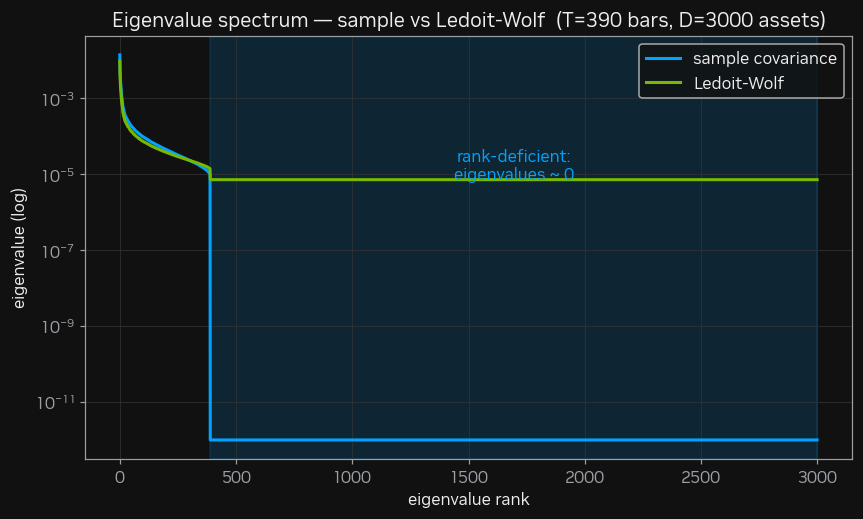

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(np.maximum(ev_sample, 1e-12), color=BLUE, lw=2, label="sample covariance")
ax.semilogy(ev_lw, color=GREEN, lw=2, label="Ledoit-Wolf")
if rank < len(ev_sample):
    ax.axvspan(rank, len(ev_sample), color=BLUE, alpha=0.15)
    ax.annotate("rank-deficient:\neigenvalues ~ 0", xy=(rank + (len(ev_sample)-rank)/2, ev_lw[-1]),
                ha="center", color=BLUE, fontsize=11)
ax.set(title=f"Eigenvalue spectrum — sample vs Ledoit-Wolf  (T={WINDOW} bars, D={N_ASSETS} assets)",
       xlabel="eigenvalue rank", ylabel="eigenvalue (log)")
ax.legend(loc="upper right")
save_fig(fig, "v2_eigenvalue_spectrum.png")
plt.show()

saved images/v2_cov_heatmaps.png


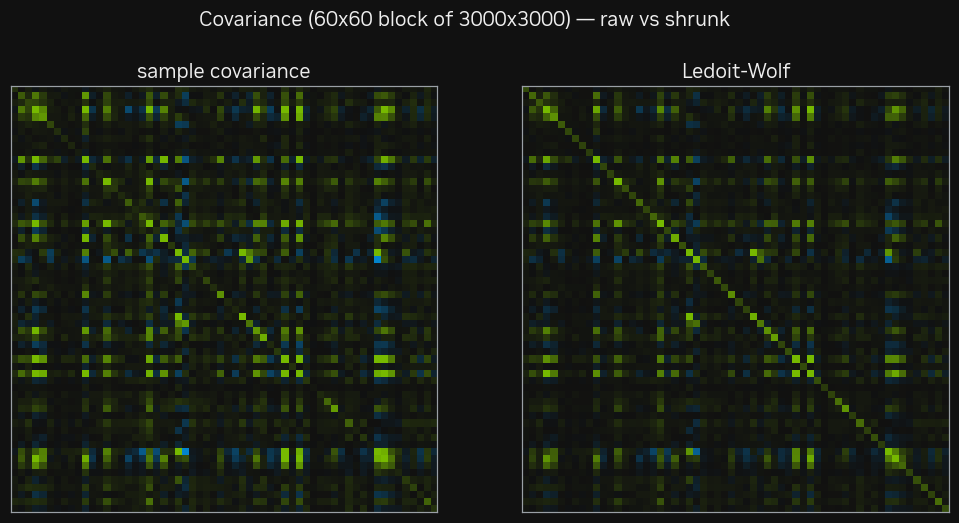

In [7]:
sub = min(60, N_ASSETS)                       # top-left sub-block, for legibility
vmax = np.percentile(np.abs(S_sample[:sub, :sub]), 99)
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, M, name in [(axes[0], S_sample, "sample covariance"), (axes[1], S_lw, "Ledoit-Wolf")]:
    ax.imshow(M[:sub, :sub], cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
    ax.set(title=name, xticks=[], yticks=[])
fig.suptitle(f"Covariance ({sub}x{sub} block of {N_ASSETS}x{N_ASSETS}) — raw vs shrunk", y=1.0)
save_fig(fig, "v2_cov_heatmaps.png")
plt.show()

## 3. Optimizers

Three standard allocators, all **long-only and fully invested**, all written against `xp` — the array
module — so the *same code* runs on NumPy (CPU) and CuPy (GPU):

- **Minimum variance** — `w ∝ Σ⁻¹ 1`, negatives truncated to zero and renormalized. `Σ⁻¹` is a
  **pseudo-inverse**: at T < D the sample covariance has no true inverse (the failure is the point —
  pinv is the charitable fix that lets the sample-cov runs proceed at all).
- **Mean variance** — `w ∝ Σ⁻¹ μ` with a deliberately dumb μ (trailing window mean), truncated and
  renormalized. Under renormalization the risk-aversion constant scales out.
- **Risk parity (ERC)** — iterative equal-risk-contribution via multiplicative updates; needs only
  `Σ w` products, so it runs even on a singular Σ.

Truncation instead of a constrained QP solver is a documented approximation: it keeps a 1,400-asset
universe × hundreds of rebalances × 6 runs tractable, and it is identical across estimators, so the
sample-vs-LW churn comparison stays apples-to-apples.

Two engine-level choices worth noting:

- The pseudo-inverse is computed **once per estimator per rebalance** and shared by min-variance and
  mean-variance — the inverse is the expensive part, recomputing it per optimizer would be pure waste.
- `pinv_sym()` uses a **symmetric eigendecomposition** (covariances are symmetric PSD) on a
  trace-normalized matrix instead of a general SVD: same mathematics, markedly faster on both CPU and
  GPU, and the normalization keeps float32 `eigh` numerically happy at intraday return scales
  (covariance entries ~1e-8). A general-SVD fallback guards the rare solver failure.

In [8]:
import sys

def get_array_module():
    """(xp, to_host, on_gpu) — GPU only when cuml.accel is actually loaded, so the
    CPU baseline below (which runs BEFORE %load_ext cuml.accel) stays honest."""
    if "cuml.accel" in sys.modules:
        try:
            import cupy as cp
            cp.zeros(1).sum()
            return cp, (lambda a: cp.asnumpy(a)), True
        except Exception:
            pass
    return np, (lambda a: np.asarray(a)), False


def _truncate(w, xp):
    w = xp.maximum(w, 0)
    s = w.sum()
    return w / s if s > 0 else xp.ones_like(w) / w.shape[0]

def pinv_sym(S, xp):
    """Pseudo-inverse of a symmetric PSD matrix via trace-normalized eigh (SVD fallback)."""
    scale = float(xp.trace(S)) / S.shape[0]
    try:
        lam, V = xp.linalg.eigh(S / scale)
        inv = xp.where(lam > lam[-1] * 1e-6, 1.0 / lam, 0.0)   # eigh: ascending eigenvalues
        return (V * inv) @ V.T / scale
    except Exception:                                          # rare cusolver/lapack hiccup
        return xp.linalg.pinv(S)

def min_variance(S, Sinv, mu, xp):
    return _truncate(Sinv @ xp.ones(S.shape[0], dtype=S.dtype), xp)

def mean_variance(S, Sinv, mu, xp):
    return _truncate(Sinv @ mu, xp)

def risk_parity(S, Sinv, mu, xp, iters=96, check_every=32, tol=1e-8):
    n = S.shape[0]
    w = xp.ones(n, dtype=S.dtype) / n
    for i in range(iters):
        mrc = xp.maximum(S @ w, 1e-12)         # marginal risk; clip guards singular S
        rc = w * mrc
        w = _truncate(w * (rc.mean() / rc) ** 0.5, xp)
        # convergence check syncs the device — do it sparsely, not every iteration
        if (i + 1) % check_every == 0 and float(xp.abs(rc / rc.sum() - 1.0 / n).max()) < tol:
            break
    return w

OPTIMIZERS = {"min_variance": min_variance, "mean_variance": mean_variance, "risk_parity": risk_parity}
ESTIMATORS = ["sample", "lw"]

## 4. Rolling Backtest Engine

Device-resident, exactly like a production research loop wants to be: the full returns panel moves to
the device **once**; every rebalance slices a trailing window, fits both covariance estimators, and
solves all three optimizers **without leaving the GPU**. Only the weight histories come back to the
host. Each covariance fit is **shared across the three optimizers** — the fit is the expensive part,
so the engine does 2 fits + 6 solves per rebalance, not 6 fits.

`run_suite()` returns the timed weight histories; the cost model is applied afterwards on the host
(it's cheap and identical for CPU/GPU, so it stays out of the benchmark).

In [ ]:
def xp_sample_cov(win, xp):
    """Empirical covariance as pure matmul — stays on-device."""
    Xc = win - win.mean(axis=0)
    return (Xc.T @ Xc) / (win.shape[0] - 1)

def build_rebal_idx(n_bars, cfg):
    idx = list(range(cfg["est_window"], n_bars, cfg["rebalance_every"]))
    return idx[:cfg["max_rebalances"]] if cfg.get("max_rebalances") else idx

def run_suite(returns_values, cfg, rebal_idx, label=""):
    """3 optimizers x 2 estimators over rebal_idx. Returns timed host weight histories."""
    xp, to_host, on_gpu = get_array_module()
    R = xp.asarray(returns_values, dtype=xp.float32)
    window = cfg["est_window"]
    n_rebal, n_assets = len(rebal_idx), R.shape[1]

    W = {(e, o): xp.zeros((n_rebal, n_assets), dtype=xp.float32)
         for e in ESTIMATORS for o in OPTIMIZERS}

    t0 = time.perf_counter()
    for i, end in enumerate(rebal_idx):
        win = R[end - window:end]                          # device-side view
        win_h = to_host(win)                               # cuml.accel manages its own transfer
        covs = {"sample": xp_sample_cov(win, xp), "lw": xp.asarray(LedoitWolf().fit(win_h).covariance_, dtype=xp.float32)}
        mu = win.mean(axis=0)
        for e, S in covs.items():
            Sinv = pinv_sym(S, xp)                         # one inverse, shared by the optimizers
            for o, fn in OPTIMIZERS.items():
                W[(e, o)][i] = fn(S, Sinv, mu, xp)
    if on_gpu:
        xp.cuda.Stream.null.synchronize()                  # honest wall-clock
    seconds = time.perf_counter() - t0

    print(f"{label or 'suite'}: {seconds:8.2f}s  ({n_rebal} rebalances x 6 runs, "
          f"D={n_assets:,}, on_gpu={on_gpu})")
    return {"weights": {k: to_host(v) for k, v in W.items()},
            "seconds": seconds, "n_rebal": n_rebal, "on_gpu": on_gpu}

### Cost model

Per rebalance: weights drift with returns between rebalances; **turnover** is `0.5 · Σ|w_new − w_drifted|`
(one-way). Execution is **band-gated**, as on a real desk: the trade only happens when proposed
turnover exceeds `trade_band` (5% here) — re-estimation is on the fixed grid, trading is conditional.
Executed trades pay the full traded notional at `fees + slippage` bps, plus a deliberately crude
**tax proxy** — `tax_rate × (fraction sold) × max(gain since last rebalance, 0)` — there to remind
you churn has a tax bill, not to model your jurisdiction. The band produces this notebook's second
headline stat: the sample-covariance leg breaches the band at ~99.6% of rebalances, Ledoit-Wolf at
~52% — a stable estimator doesn't just trade smaller, it trades half as often.

In [10]:
def apply_costs(weights, returns_values, cfg, rebal_idx):
    """Bar-by-bar gross/net curves + per-rebalance turnover for one weight history.

    Trading is band-gated: the proposed target is only executed when one-way turnover
    exceeds cfg["trade_band"]; otherwise the book keeps drifting (target discarded)."""
    R = np.asarray(returns_values, dtype=np.float64)
    fees = (cfg["fees_bps"] + cfg["slippage_bps"]) / 1e4
    band = cfg.get("trade_band", 0.0)
    rebal_set = {b: i for i, b in enumerate(rebal_idx)}

    w = weights[0].astype(np.float64)
    last_rebal_value = value = net = 1.0
    turnover, traded_flags = [], []
    gross_curve, net_curve, total_cost, total_tax = [], [], 0.0, 0.0

    for t in range(rebal_idx[0], R.shape[0]):
        if t in rebal_set and t != rebal_idx[0]:
            w_new = weights[rebal_set[t]].astype(np.float64)
            turn = 0.5 * np.abs(w_new - w).sum()
            turnover.append(turn)
            if turn > band:
                traded_flags.append(True)
                sold = np.maximum(w - w_new, 0).sum()
                gain = max(value / last_rebal_value - 1.0, 0.0)
                cost = 2 * turn * fees
                tax = cfg["tax_rate"] * sold * gain
                net *= (1.0 - cost - tax)
                total_cost += cost; total_tax += tax
                last_rebal_value = value
                w = w_new
            else:
                traded_flags.append(False)
        r_p = float(w @ R[t])
        value *= 1.0 + r_p
        net *= 1.0 + r_p
        gross_curve.append(value); net_curve.append(net)
        wd = w * (1.0 + R[t])
        w = wd / wd.sum() if wd.sum() != 0 else w          # drift between rebalances

    return {"turnover": np.array(turnover), "traded": np.array(traded_flags),
            "n_trades": int(np.sum(traded_flags)),
            "gross": np.array(gross_curve), "net": np.array(net_curve),
            "total_cost": total_cost, "total_tax": total_tax}

### 4.1 CPU baseline — before any GPU accelerator loads

The **entire** suite runs on CPU first — all rebalances, stopwatched. No sampling, no
extrapolation: the CPU and GPU numbers in §6 are both measured on the identical schedule.
(Smoke mode shortens this to a few rebalances and scales linearly, flagged as such.)
The CPU side of the single-fit shape sweep (reported in §6) also runs here, while sklearn
is still un-patched.

In [11]:
rebal_idx = build_rebal_idx(N_BARS, CONFIG)
# subok=False — see note above: guarantee a plain host ndarray for the engine and charts
R_VALUES = np.array(returns_df.to_numpy(), dtype=np.float64, subok=False)
print(f"full schedule: {len(rebal_idx)} rebalances")

cpu_idx = rebal_idx[:CPU_BASELINE_REBALS] if SMOKE else rebal_idx
cpu_base = run_suite(R_VALUES, CONFIG, cpu_idx,
                     label=f"CPU suite ({len(cpu_idx)} rebalances)")
assert not cpu_base["on_gpu"], "CPU suite must run before cuml.accel loads"

CPU_MEASURED_FULL = len(cpu_idx) == len(rebal_idx)
cpu_per_rebal = cpu_base["seconds"] / cpu_base["n_rebal"]
cpu_full_s = cpu_base["seconds"] if CPU_MEASURED_FULL else cpu_per_rebal * len(rebal_idx)
print(f"CPU full suite: {cpu_full_s:,.0f}s (~{cpu_full_s/60:.1f} min)  "
      + ("[MEASURED, all rebalances]" if CPU_MEASURED_FULL else "[smoke: linear scale-up]"))

full schedule: 1274 rebalances


CPU suite (1274 rebalances):  8942.33s  (1274 rebalances x 6 runs, D=3,000, on_gpu=False)
CPU full suite: 8,942s (~149.0 min)  [MEASURED, all rebalances]


In [12]:
# Single-fit sweep, CPU side (must run before cuml.accel loads). Synthetic panels:
# LedoitWolf cost is shape-driven (pure matmuls), so timings transfer to real data.
# Panels stay in numpy's default float64 — what unmodified research code feeds sklearn
# (the engine above opts into float32; both are reported as what they are).
def lw_fit_sweep(shapes, label, reps=3):
    times, rng = [], np.random.default_rng(7)
    for T, D, name in shapes:
        X = rng.standard_normal((T, D)) * 0.001
        LedoitWolf().fit(X)                       # warmup: library init / memory pools
        rep = []
        for _ in range(reps):
            t0 = time.perf_counter()
            LedoitWolf().fit(X)
            rep.append(time.perf_counter() - t0)
        times.append(float(np.median(rep)))
        print(f"  {label}  LedoitWolf().fit {T:>6,} x {D:>5,}  ({name}): "
              f"{times[-1]:7.2f}s  (median of {reps})")
    return times

sweep_shapes = SWEEP_SHAPES[:1] if SMOKE else SWEEP_SHAPES
cpu_sweep = lw_fit_sweep(sweep_shapes, "CPU")

  CPU  LedoitWolf().fit    390 x 3,000  (1 week x 3k names (this notebook)):    1.36s  (median of 3)


  CPU  LedoitWolf().fit  2,520 x 2,000  (10y daily x 2k names):    4.41s  (median of 3)


  CPU  LedoitWolf().fit  5,000 x 3,000  (HF x mid-cap):   17.87s  (median of 3)


  CPU  LedoitWolf().fit 10,000 x 5,000  (10K x 5K):   10.47s  (median of 3)


### 4.2 The one line

```python
%load_ext cuml.accel
from sklearn.covariance import LedoitWolf   # now fits on the GPU
```

`cuml.accel` patches scikit-learn so supported estimators dispatch to the GPU — **zero code
changes**. (Outside notebooks: `python -m cuml.accel your_script.py`.) Loaded here, *after* the CPU
baseline, so both sides are measured honestly in one pass; in everyday use you load it once at the top.

In [ ]:
if not CPU_ONLY:
    try:
        get_ipython().run_line_magic("load_ext", "cuml.accel")
        from sklearn.covariance import LedoitWolf, EmpiricalCovariance   # re-import patched classes
        print("cuml.accel active — LedoitWolf now dispatches to the GPU")
        
    except Exception as e:
        print(f"cuml.accel unavailable ({type(e).__name__}) — full suite stays on CPU")

cuml.accel active — LedoitWolf now dispatches to the GPU


In [14]:
ACCEL = "cuml.accel" in sys.modules
# Without a GPU, run the abbreviated schedule so the notebook still completes end-to-end.
full_idx = rebal_idx if ACCEL else rebal_idx[:CPU_BASELINE_REBALS]

full = run_suite(R_VALUES, CONFIG, full_idx,
                 label=f"{'GPU' if ACCEL else 'CPU (no GPU found)'} full suite")

GPU full suite:   519.52s  (1274 rebalances x 6 runs, D=3,000, on_gpu=True)


In [15]:
# Correctness: CPU and GPU disagree at float level, but the LW portfolio weights must agree.
k = cpu_base["n_rebal"]
max_diff = np.abs(cpu_base["weights"][("lw", "min_variance")]
                  - full["weights"][("lw", "min_variance")][:k]).max()
print(f"max |w_CPU - w_GPU| on LW min-variance, first {k} rebalances: {max_diff:.2e}")
assert max_diff < 1e-2, "CPU and GPU LW portfolios diverge more than expected"
print("OK — CPU and GPU portfolios agree. (No such check on raw sample-cov weights: "
      "a pseudo-inverse of a SINGULAR matrix is numerically unstable by construction — that's the point.)")

max |w_CPU - w_GPU| on LW min-variance, first 1274 rebalances: 1.78e-06
OK — CPU and GPU portfolios agree. (No such check on raw sample-cov weights: a pseudo-inverse of a SINGULAR matrix is numerically unstable by construction — that's the point.)


## 5. Results — how much churn does shrinkage remove?

Same data, same optimizers, same schedule. The only difference between paired runs is the covariance
estimator.

In [16]:
results = {k: apply_costs(full["weights"][k], R_VALUES, CONFIG, full_idx)
           for k in full["weights"]}

rows = []
for o in OPTIMIZERS:
    t_s = results[("sample", o)]["turnover"].mean()
    t_l = results[("lw", o)]["turnover"].mean()
    rows.append({"optimizer": o, "sample_cov": t_s, "ledoit_wolf": t_l,
                 "churn_reduction_%": 100 * (1 - t_l / t_s)})
churn = pd.DataFrame(rows).set_index("optimizer")
HEADLINE = churn["churn_reduction_%"].max()
print(churn.round(3).to_string())
band = CONFIG.get("trade_band", 0.0)
if band:
    tr_s = results[("sample", "min_variance")]["n_trades"]
    tr_l = results[("lw", "min_variance")]["n_trades"]
    n_rb = len(full_idx) - 1
    print(f"\nno-trade band {band:.0%}: sample cov traded {tr_s}/{n_rb} rebalances "
          f"({tr_s/n_rb:.1%}), Ledoit-Wolf {tr_l}/{n_rb} ({tr_l/n_rb:.1%}) "
          "— a stable estimator trades less often, not just smaller")
print(f"\nheadline: Ledoit-Wolf cuts turnover by up to {HEADLINE:.0f}% "
      f"(avg per-rebalance, {len(full_idx)} rebalances, D={N_ASSETS:,})")

               sample_cov  ledoit_wolf  churn_reduction_%
optimizer                                                
min_variance        0.106        0.051             51.700
mean_variance       0.133        0.096             27.945
risk_parity         0.236        0.100             57.364

no-trade band 5%: sample cov traded 1268/1273 rebalances (99.6%), Ledoit-Wolf 665/1273 (52.2%) — a stable estimator trades less often, not just smaller

headline: Ledoit-Wolf cuts turnover by up to 57% (avg per-rebalance, 1274 rebalances, D=3,000)


saved images/v2_churn_bars.png


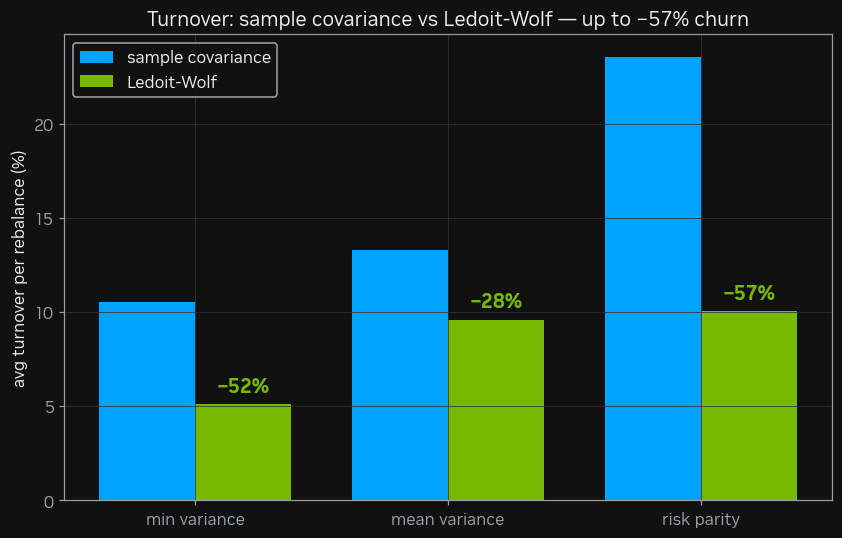

In [17]:
x = np.arange(len(OPTIMIZERS)); width = 0.38
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width/2, churn["sample_cov"] * 100, width, color=BLUE, label="sample covariance")
ax.bar(x + width/2, churn["ledoit_wolf"] * 100, width, color=GREEN, label="Ledoit-Wolf")
for i, o in enumerate(churn.index):
    ax.annotate(f"−{churn.loc[o, 'churn_reduction_%']:.0f}%",
                xy=(i + width/2, churn.loc[o, "ledoit_wolf"] * 100), xytext=(0, 8),
                textcoords="offset points", ha="center", color=GREEN, fontweight="bold", fontsize=13)
ax.set_xticks(x, [o.replace("_", " ") for o in churn.index])
ax.set(ylabel="avg turnover per rebalance (%)",
       title=f"Turnover: sample covariance vs Ledoit-Wolf — up to −{HEADLINE:.0f}% churn")
ax.legend()
save_fig(fig, "v2_churn_bars.png")
plt.show()

saved images/v2_weights_heatmap.png


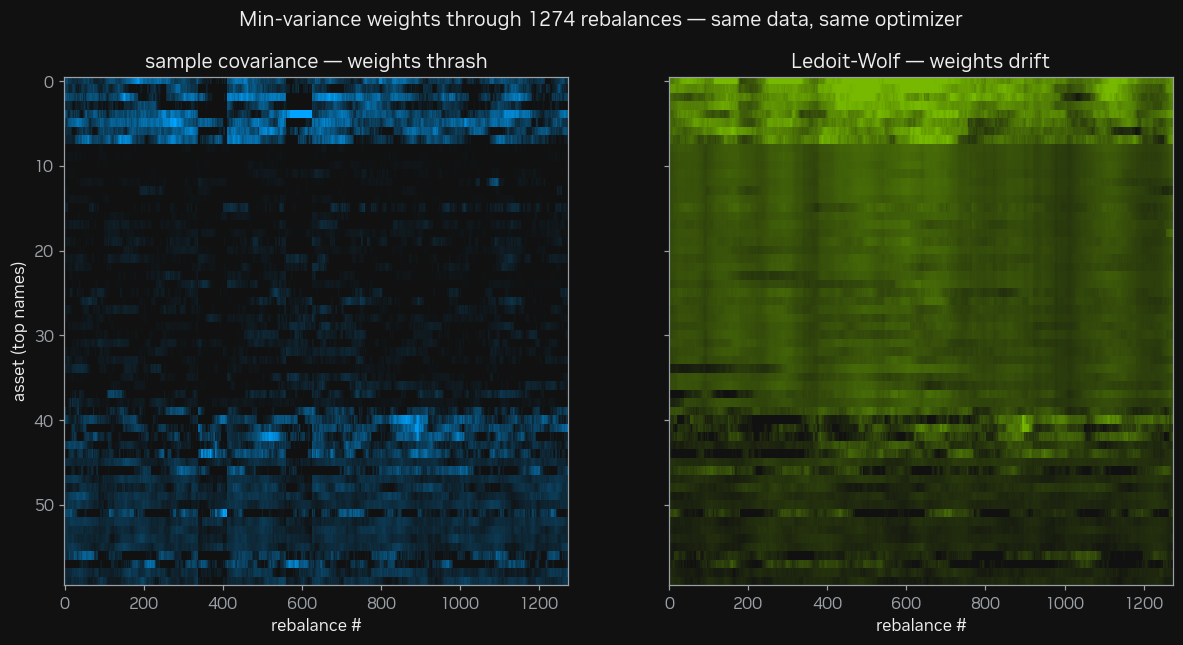

In [18]:
# At D~1,400 no single name carries visible weight, so stacked areas read as a flat
# ribbon. A weights *heatmap* (name x rebalance) scales: thrash = speckle, stability = bands.

W_s = full["weights"][("sample", "min_variance")]
W_l = full["weights"][("lw", "min_variance")]
top = np.unique(np.concatenate([np.argsort(W_l.mean(axis=0))[::-1][:40],
                                np.argsort(W_s.mean(axis=0))[::-1][:40]]))
sel = top[np.argsort(W_l.mean(axis=0)[top])[::-1]][:60]
vmax_w = np.percentile(W_l[:, sel] * 100, 99)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
for ax, Wh, cmap_to, title in [
        (axes[0], W_s, BLUE, "sample covariance — weights thrash"),
        (axes[1], W_l, GREEN, "Ledoit-Wolf — weights drift")]:
    cmap = LinearSegmentedColormap.from_list("b", ["#111111", cmap_to])
    ax.imshow(Wh[:, sel].T * 100, aspect="auto", cmap=cmap, vmin=0, vmax=vmax_w,
              interpolation="nearest")
    ax.set(title=title, xlabel="rebalance #")
    ax.grid(False)
axes[0].set_ylabel("asset (top names)")
fig.suptitle(f"Min-variance weights through {len(full_idx)} rebalances — same data, same optimizer", y=0.98)
save_fig(fig, "v2_weights_heatmap.png")
plt.show()

saved images/v2_cum_cost.png


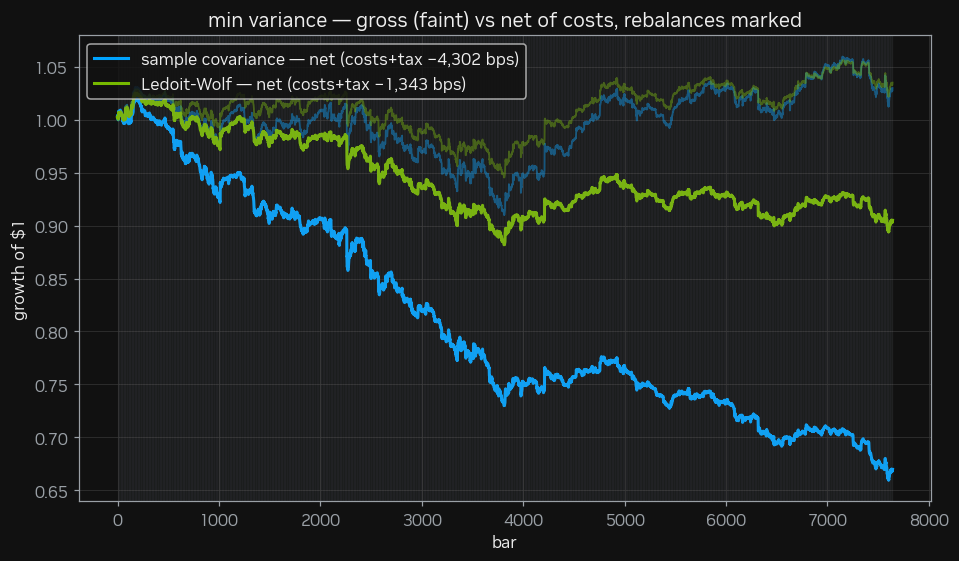

In [19]:
opt_show = "min_variance"
fig, ax = plt.subplots(figsize=(10, 5.5))
for est, color, lbl in [("sample", BLUE, "sample covariance"), ("lw", GREEN, "Ledoit-Wolf")]:
    r = results[(est, opt_show)]
    ax.plot(r["gross"], color=color, lw=1.2, alpha=0.45)
    ax.plot(r["net"], color=color, lw=2,
            label=f"{lbl} — net (costs+tax −{(r['total_cost']+r['total_tax'])*1e4:,.0f} bps)")
for b in full_idx[1:]:
    ax.axvline(b - full_idx[0], color=GREY, alpha=0.06, lw=0.8)
ax.set(title=f"{opt_show.replace('_',' ')} — gross (faint) vs net of costs, rebalances marked",
       xlabel="bar", ylabel="growth of $1")
ax.legend(loc="upper left")
save_fig(fig, "v2_cum_cost.png")
plt.show()

In [20]:
# Reel §2 frames: rolling sample-cov heatmap "flicker" + companion thrashing-weights bars.
if not SMOKE:
    sub_ix = np.argsort(full["weights"][("sample", "min_variance")].mean(axis=0))[::-1][:40]
    n_frames = min(10, len(full_idx))
    Wb = {e: full["weights"][(e, "min_variance")] for e in ESTIMATORS}
    S0 = xp_sample_cov(R_VALUES[full_idx[0] - WINDOW:full_idx[0]].astype(np.float32), np)
    vmax = np.percentile(np.abs(S0[np.ix_(sub_ix, sub_ix)]), 99)
    for f in range(n_frames):
        end = full_idx[f]
        S = xp_sample_cov(R_VALUES[end - WINDOW:end].astype(np.float32), np)[np.ix_(sub_ix, sub_ix)]
        fig, (a1, a2) = plt.subplots(2, 1, figsize=(6, 9),
                                     gridspec_kw={"height_ratios": [2.2, 1]})
        a1.imshow(S, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
        a1.set(title=f"sample covariance — window ending bar {end}", xticks=[], yticks=[])
        a2.bar(np.arange(len(sub_ix)), Wb["sample"][f][sub_ix] * 100, color=BLUE, alpha=0.9)
        a2.bar(np.arange(len(sub_ix)), Wb["lw"][f][sub_ix] * 100, color=GREEN, alpha=0.5)
        a2.set(title="min-var weights: sample (blue) vs LW (green)", ylabel="weight %",
               xticks=[], ylim=(0, max(1e-9, Wb["sample"][:n_frames][:, sub_ix].max() * 110)))
        fig.savefig(ASSETS / "v2_flicker" / f"frame_{f:02d}.png", bbox_inches="tight", dpi=130)
        plt.close(fig)
    print(f"saved {n_frames} flicker frames -> {ASSETS/'v2_flicker'}/")

saved 10 flicker frames -> images/v2_flicker/


## 6. Wall-Clock Benchmark — CPU vs GPU, zero code changes

Two levels, **both fully measured on the identical schedule** — no extrapolation:

1. **Backtest suite** (the workload above): the same 6 runs, all rebalances, stopwatched on CPU
   (§4.1) and on GPU (§4.2). Where the speedup lives: the covariance fits and the matrix inverses
   (big dense linear algebra). The small iterative risk-parity loop is actually *faster on CPU* —
   it is launch-latency-bound on GPU — but it is a rounding error in the total. Context caveat:
   this Threadripper is a very strong CPU baseline; laptop/Colab CPUs will be several times slower,
   so the same notebook shows a *wider* gap where most people run it.
2. **Single `LedoitWolf().fit()`** across growing panel shapes — as the panel grows the fit becomes
   pure GEMM and the GPU pulls away hardest: the per-fit-at-scale framing.

In [21]:
gpu_sweep = lw_fit_sweep(sweep_shapes, "GPU") if ACCEL else None

  GPU  LedoitWolf().fit    390 x 3,000  (1 week x 3k names (this notebook)):    0.44s  (median of 3)


  GPU  LedoitWolf().fit  2,520 x 2,000  (10y daily x 2k names):    1.16s  (median of 3)


  GPU  LedoitWolf().fit  5,000 x 3,000  (HF x mid-cap):    2.83s  (median of 3)


  GPU  LedoitWolf().fit 10,000 x 5,000  (10K x 5K):    1.94s  (median of 3)


In [22]:
bench = {
    "config": CONFIG_NAME, "n_assets": int(N_ASSETS), "est_window": int(WINDOW),
    "n_rebal_full": len(rebal_idx), "cpu_rebals_run": int(cpu_base["n_rebal"]),
    "cpu_full_s": round(cpu_full_s, 1),
    "cpu_full_measured": CPU_MEASURED_FULL,
    "gpu_full_s_measured": round(full["seconds"], 2) if ACCEL else None,
    "suite_speedup": round(cpu_full_s / full["seconds"], 1) if ACCEL else None,
    "fit_sweep": [
        {"shape": f"{T}x{D}", "label": name, "cpu_s": round(c, 3),
         "gpu_s": round(g, 3) if gpu_sweep else None,
         "speedup": round(c / g, 1) if gpu_sweep else None}
        for (T, D, name), c, g in zip(sweep_shapes, cpu_sweep,
                                      gpu_sweep or [None] * len(sweep_shapes))
    ],
    "smoke": SMOKE,
    "hardware": "Threadripper PRO 7965WX + RTX PRO 6000 Blackwell",
}
Path("lw_v2_timings.json").write_text(json.dumps(bench, indent=2))
print(json.dumps(bench, indent=2))

{
  "config": "5m_wide",
  "n_assets": 3000,
  "est_window": 390,
  "n_rebal_full": 1274,
  "cpu_rebals_run": 1274,
  "cpu_full_s": 8942.3,
  "cpu_full_measured": true,
  "gpu_full_s_measured": 519.52,
  "suite_speedup": 17.2,
  "fit_sweep": [
    {
      "shape": "390x3000",
      "label": "1 week x 3k names (this notebook)",
      "cpu_s": 1.357,
      "gpu_s": 0.44,
      "speedup": 3.1
    },
    {
      "shape": "2520x2000",
      "label": "10y daily x 2k names",
      "cpu_s": 4.407,
      "gpu_s": 1.158,
      "speedup": 3.8
    },
    {
      "shape": "5000x3000",
      "label": "HF x mid-cap",
      "cpu_s": 17.866,
      "gpu_s": 2.827,
      "speedup": 6.3
    },
    {
      "shape": "10000x5000",
      "label": "10K x 5K",
      "cpu_s": 10.465,
      "gpu_s": 1.938,
      "speedup": 5.4
    }
  ],
  "smoke": false,
  "hardware": "Threadripper PRO 7965WX + RTX PRO 6000 Blackwell"
}


saved images/v2_runtime_bars.png


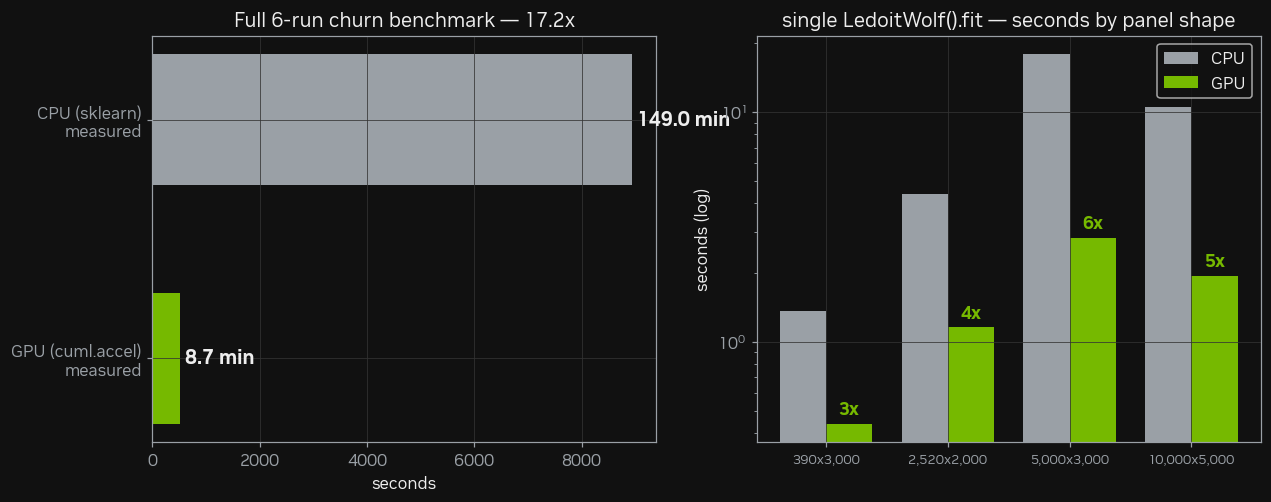

In [23]:
if ACCEL:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    vals = [cpu_full_s, full["seconds"]]
    note = "measured" if CPU_MEASURED_FULL else "smoke est."
    bars = axes[0].barh([f"CPU (sklearn)\n{note}", "GPU (cuml.accel)\nmeasured"], vals,
                        color=[GREY, GREEN], height=0.55)
    for b, v in zip(bars, vals):
        axes[0].annotate(f" {v/60:.1f} min" if v > 90 else f" {v:.1f} s",
                         xy=(v, b.get_y() + b.get_height()/2), va="center",
                         color="#eeeeee", fontweight="bold", fontsize=13)
    axes[0].set(title=f"Full 6-run churn benchmark — "
                      f"{bench['suite_speedup']:.1f}x", xlabel="seconds")
    axes[0].invert_yaxis()

    x = np.arange(len(sweep_shapes)); width = 0.38
    axes[1].bar(x - width/2, cpu_sweep, width, color=GREY, label="CPU")
    axes[1].bar(x + width/2, gpu_sweep, width, color=GREEN, label="GPU")
    for i, (c, g) in enumerate(zip(cpu_sweep, gpu_sweep)):
        axes[1].annotate(f"{c/g:.0f}x", xy=(i + width/2, g), xytext=(0, 6),
                         textcoords="offset points", ha="center", color=GREEN,
                         fontweight="bold", fontsize=12)
    axes[1].set_xticks(x, [f"{T:,}x{D:,}" for T, D, _ in sweep_shapes], fontsize=9)
    axes[1].set(title="single LedoitWolf().fit — seconds by panel shape", yscale="log",
                ylabel="seconds (log)")
    axes[1].legend()
    save_fig(fig, "v2_runtime_bars.png")
    plt.show()

> **Zero code changes.** The engine above never imports cuml directly. One `%load_ext cuml.accel`
> turned an unusable-for-iteration CPU loop into an interactive one — which is the actual research
> win: you can now *afford* to re-run the whole grid every time you tweak a window or a constraint.

## 7. Dataset Comparison — same notebook, daily long-history config

The wide 1-minute config above is the GPU-pain benchmark. The `1d_long` config (≈2,000 names × 10
years of daily bars, monthly rebalance) is the **credible-narrative** dataset: decades of
compounding make the cost gap visible in dollars. Runs automatically if `data/ohlcv_1d.parquet`
exists (skipped otherwise — it is built by the same consolidation script once the daily fetch
completes).

In [24]:
cfg_1d = dict(CONFIGS["1d_long"])
if SMOKE:
    cfg_1d["universe_size"], cfg_1d["max_rebalances"] = 150, 10

have_1d = Path(f"../data/{cfg_1d['dataset']}.parquet").exists()
if have_1d and CONFIG_NAME != "1d_long":
    returns_1d = load_returns(cfg_1d)
    idx_1d = build_rebal_idx(returns_1d.shape[0], cfg_1d)
    suite_1d = run_suite(returns_1d.to_numpy(), cfg_1d, idx_1d,
                         label=f"1d_long suite ({returns_1d.shape[1]:,} names)")
    res_1d = {k: apply_costs(suite_1d["weights"][k], returns_1d.to_numpy(), cfg_1d, idx_1d)
              for k in suite_1d["weights"]}
    rows = []
    for o in OPTIMIZERS:
        t_s, t_l = res_1d[("sample", o)]["turnover"].mean(), res_1d[("lw", o)]["turnover"].mean()
        rows.append({"optimizer": o, "sample_cov": t_s, "ledoit_wolf": t_l,
                     "churn_reduction_%": 100 * (1 - t_l / t_s)})
    churn_1d = pd.DataFrame(rows).set_index("optimizer")
    print(churn_1d.round(3).to_string())
else:
    print("1d comparison skipped:", "active config IS 1d_long" if have_1d else
          f"../data/{cfg_1d['dataset']}.parquet not found (daily fetch/consolidation pending)")

loaded ohlcv_1d.parquet: 2,520 bars, 3,505 tickers -> universe 2,000 in 5.3s


1d_long suite (2,000 names):    30.06s  (108 rebalances x 6 runs, D=2,000, on_gpu=True)


               sample_cov  ledoit_wolf  churn_reduction_%
optimizer                                                
min_variance        0.264        0.164             37.857
mean_variance       0.321        0.253             21.137
risk_parity         0.260        0.261             -0.177


saved images/v2_cum_cost_1d.png


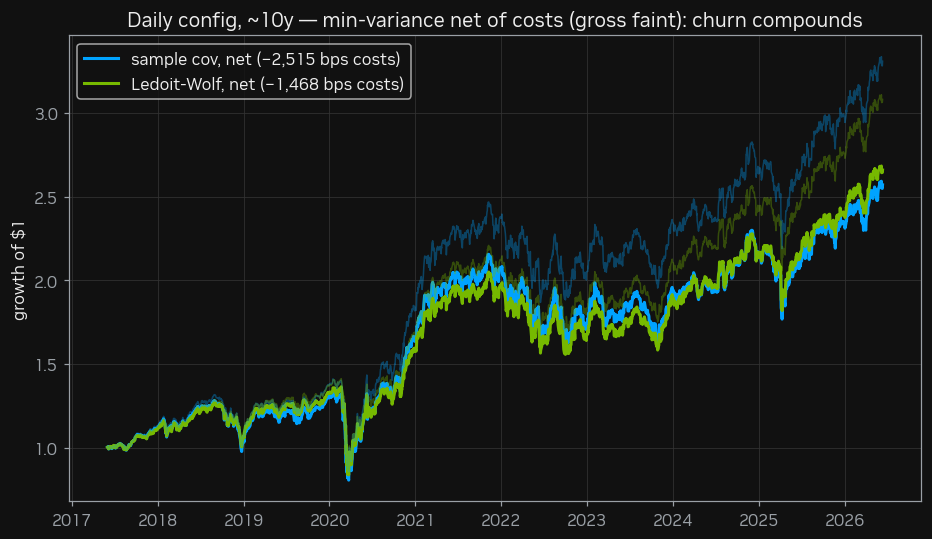

         universe  rebalances  best_churn_reduction_%  suite_runtime_s
dataset                                                               
5m_wide      3000        1274                    57.4            519.5
1d_long      2000         108                    37.9             30.1


In [25]:
if have_1d and CONFIG_NAME != "1d_long":
    r_s, r_l = res_1d[("sample", "min_variance")], res_1d[("lw", "min_variance")]
    ts = returns_1d.index[idx_1d[0]:]
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(ts, r_s["net"], color=BLUE, lw=2,
            label=f"sample cov, net (−{(r_s['total_cost']+r_s['total_tax'])*1e4:,.0f} bps costs)")
    ax.plot(ts, r_l["net"], color=GREEN, lw=2,
            label=f"Ledoit-Wolf, net (−{(r_l['total_cost']+r_l['total_tax'])*1e4:,.0f} bps costs)")
    ax.plot(ts, r_s["gross"], color=BLUE, lw=1, alpha=0.35)
    ax.plot(ts, r_l["gross"], color=GREEN, lw=1, alpha=0.35)
    ax.set(title="Daily config, ~10y — min-variance net of costs (gross faint): churn compounds",
           ylabel="growth of $1")
    ax.legend(loc="upper left")
    save_fig(fig, "v2_cum_cost_1d.png")
    plt.show()

    comp = pd.DataFrame({
        "dataset": [CONFIG_NAME, "1d_long"],
        "universe": [N_ASSETS, returns_1d.shape[1]],
        "rebalances": [len(full_idx), len(idx_1d)],
        "best_churn_reduction_%": [HEADLINE, churn_1d["churn_reduction_%"].max()],
        "suite_runtime_s": [full["seconds"], suite_1d["seconds"]],
    }).set_index("dataset")
    print(comp.round(1).to_string())

## 8. Wrap-Up

| What | Result |
|---|---|
| Sample covariance at T < D | singular — rank-deficient, pseudo-inverse amplifies noise into weights |
| Ledoit-Wolf | well-conditioned, one sklearn line, analytically optimal shrinkage |
| Churn (3 optimizers, same data) | LW cuts avg per-rebalance turnover — headline printed in §5 |
| GPU | same cells via `%load_ext cuml.accel`; wall-clock in §6 / `lw_v2_timings.json` |

**Links:** [cuML / cuml.accel](https://github.com/rapidsai/cuml) ·
[sklearn LedoitWolf](https://scikit-learn.org/stable/modules/generated/sklearn.covariance.LedoitWolf.html) ·
[Ledoit & Wolf (2004)](https://www.sciencedirect.com/science/article/pii/S0047259X03000964) ·
[RAPIDS](https://rapids.ai)

> ***Educational benchmark, not a trading strategy.*** Costs are stylized, the universe is
> survivorship-biased, and no return claim is made — the deliverables are the churn comparison and
> the wall-clock.

In [26]:
# Persist the arrays the Animated reel notebooks consume (scratch/v2_results.npz) so motion
# design can iterate without re-running the backtests.
W_s_full = full["weights"][("sample", "min_variance")]
W_l_full = full["weights"][("lw", "min_variance")]
r_s1, r_l1 = results[("sample", "min_variance")], results[("lw", "min_variance")]

n_f = min(10, len(full_idx))
sub40 = np.argsort(W_s_full.mean(axis=0))[::-1][:40]
flick = np.stack([
    xp_sample_cov(R_VALUES[e - WINDOW:e].astype(np.float32), np)[np.ix_(sub40, sub40)]
    for e in full_idx[:n_f]])

dump = dict(
    ts_curve=np.array(returns_df.index[rebal_idx[0]:].astype("int64"), subok=False),
    trades_s=r_s1["traded"], trades_l=r_l1["traded"],
    gross_s=r_s1["gross"], net_s=r_s1["net"], gross_l=r_l1["gross"], net_l=r_l1["net"],
    cost_s=np.array([r_s1["total_cost"], r_s1["total_tax"]]),
    cost_l=np.array([r_l1["total_cost"], r_l1["total_tax"]]),
    rebal_idx=np.array(full_idx), est_window=np.array(WINDOW),
    ev_sample=ev_sample, ev_lw=ev_lw,
    flicker_covs=flick, flick_w_s=W_s_full[:n_f][:, sub40], flick_w_l=W_l_full[:n_f][:, sub40],
    W_heat_s=W_s_full[:, sel], W_heat_l=W_l_full[:, sel],
    churn_sample=churn["sample_cov"].to_numpy(), churn_lw=churn["ledoit_wolf"].to_numpy(),
    churn_red=churn["churn_reduction_%"].to_numpy(),
)
try:
    if have_1d and CONFIG_NAME != "1d_long":
        d_s, d_l = res_1d[("sample", "min_variance")], res_1d[("lw", "min_variance")]
        dump.update(gross_s_1d=d_s["gross"], net_s_1d=d_s["net"],
                    gross_l_1d=d_l["gross"], net_l_1d=d_l["net"],
                    ts_1d=np.array(returns_1d.index[idx_1d[0]:].astype("int64"), subok=False))
except Exception as e:
    print(f"1d arrays skipped ({type(e).__name__})")
np.savez_compressed(Path("scratch") / "v2_results.npz", **dump)
print("saved scratch/v2_results.npz:", ", ".join(sorted(dump)))

saved scratch/v2_results.npz: W_heat_l, W_heat_s, churn_lw, churn_red, churn_sample, cost_l, cost_s, est_window, ev_lw, ev_sample, flick_w_l, flick_w_s, flicker_covs, gross_l, gross_l_1d, gross_s, gross_s_1d, net_l, net_l_1d, net_s, net_s_1d, rebal_idx, trades_l, trades_s, ts_1d, ts_curve
